# Manuscript revision analyses

This notebook contains only analyses that support the revised manuscript.

**Main manuscript figures**
1. Paired no-RAG ablation across evaluation dimensions.
2. Repeated-run routing stability.

Other visualisations are retained only as supplementary/reproducibility material.

**Study data**
- Original computational evaluation: 500 synthetic profiles.
- Paired no-RAG ablation: 50 fixed profiles, WITH vs WITHOUT RAG.
- Repeated-run experiment: 100 fixed profiles × 5 replays = 500 runs.

The notebook reads final analysis tables only and makes no API calls.


In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from IPython.display import display, Markdown

BASE = Path.cwd()
OUT = BASE / "outputs" if (BASE / "outputs").exists() else BASE
TABLES = OUT / "analysis_tables.xlsx"
SUMMARY = OUT / "analysis_summary.json"
FIG_MAIN = BASE / "figures" / "main_manuscript"
FIG_SUPP = BASE / "figures" / "supplementary"
FIG_MAIN.mkdir(parents=True, exist_ok=True)
FIG_SUPP.mkdir(parents=True, exist_ok=True)

xl = pd.ExcelFile(TABLES)
summary = json.loads(SUMMARY.read_text(encoding="utf-8"))

plt.rcParams.update({
    "figure.figsize": (6.5, 4.2),
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.8,
    "ytick.labelsize": 8.8,
    "legend.fontsize": 8.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def read_sheet(name):
    return pd.read_excel(TABLES, sheet_name=name)

def save_figure(fig, stem, manuscript=True):
    fig.tight_layout()
    target = FIG_MAIN if manuscript else FIG_SUPP
    fig.savefig(target / f"{stem}.png", dpi=600, bbox_inches="tight")
    plt.show()


## 1. Original 500-case evaluation

The original evaluation remains the primary computational experiment.  
Only its core numerical results are needed in the paper; the routing chart is supplementary.


In [13]:
routing = read_sheet("Routing")
issue_severity = read_sheet("Issue_Severity")
source_support = read_sheet("Source_Support")
arithmetic = read_sheet("Arithmetic")

display(Markdown("**Routing outcomes**"))
display(routing)

display(Markdown("**Issue severity**"))
display(issue_severity)

display(Markdown("**Source-support issues by route**"))
display(source_support)

display(Markdown("**Deterministic arithmetic checks**"))
display(arithmetic)


**Routing outcomes**

,case_status,n_cases,pct
0,accepted,327,65.4
1,needs_review,170,34.0
2,flagged,3,0.6


**Issue severity**

,severity,accepted,needs_review,flagged,total_issues
0,low,368,231,3,602
1,medium,1,21,3,25
2,high,0,0,0,0


**Source-support issues by route**

,issue_type,accepted_cases,needs_review_cases,flagged_cases,total_cases_with_type,total_issues_of_type
0,unsupported_claim,260,62,0,322,331
1,missing_citation,0,147,3,150,151
2,untrusted_source,0,0,0,0,0


**Deterministic arithmetic checks**

,metric,value
0,total cases,500
1,cases with deterministic section repair (repai...,10
2,cases with deterministic arithmetic mismatch f...,0
3,cases with NO arithmetic mismatch,500
4,pct with arithmetic mismatch,0
5,pct with section repair,2
6,cases with structured quick_budget_check present,500
7,max |claimed-computed expenses| (PLN) across c...,0
8,mean |claimed-computed expenses| (PLN),0


### Supplementary figure S1 — original routing distribution
This chart is useful for repository transparency but is not required in the main manuscript.


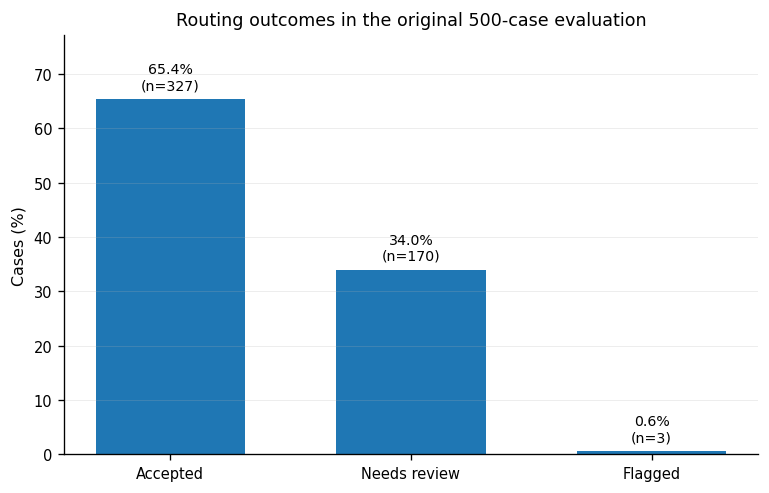

In [14]:
labels = ["Accepted", "Needs review", "Flagged"]
order = ["accepted", "needs_review", "flagged"]
vals = [routing.loc[routing.case_status==s, "pct"].iloc[0] for s in order]
counts = [routing.loc[routing.case_status==s, "n_cases"].iloc[0] for s in order]

fig, ax = plt.subplots()
bars = ax.bar(labels, vals, width=0.62)
ax.set_ylabel("Cases (%)")
ax.set_ylim(0, max(vals)*1.18)
ax.set_title("Routing outcomes in the original 500-case evaluation")
ax.grid(axis="y")
for bar, p, n in zip(bars, vals, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
            f"{p:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=8.5)
save_figure(fig, "fig1_original_routing", manuscript=False)


### Manuscript interpretation

No high-severity evaluator issue occurred in the 500-case dataset.  
The near-perfect arithmetic-consistency result must be attributed primarily to deterministic recomputation of the budget block rather than unaided LLM numerical reasoning.


## 2. Paired no-RAG ablation

Fifty fixed profiles were evaluated under two conditions. The manipulation was access to retrieved external evidence; the deterministic arithmetic safeguard, Evaluator, scoring rules, and routing thresholds were kept unchanged.


In [15]:
baseline_scores = read_sheet("Baseline_Scores")
baseline_stats = read_sheet("Baseline_Stats")
baseline_routing = read_sheet("Baseline_Routing")
baseline_route_summary = read_sheet("Baseline_Routing_Summary")

display(Markdown("**Scores by condition**"))
display(baseline_scores)

display(Markdown("**Paired statistical tests and effect sizes**"))
display(baseline_stats[baseline_stats["metric"].isin([
    "overall_score", "score_groundedness", "score_arithmetic_consistency",
    "score_actionability", "score_clarity", "score_safety_ethics"
])])

display(Markdown("**Routing by condition**"))
display(baseline_routing)

display(Markdown("**Pairwise routing direction**"))
display(baseline_route_summary)


**Scores by condition**

,condition,n,overall_score__mean,score_groundedness__mean,score_arithmetic_consistency__mean,score_actionability__mean,score_clarity__mean,score_safety_ethics__mean,overall_score__median,score_groundedness__median,score_arithmetic_consistency__median,score_actionability__median,score_clarity__median,score_safety_ethics__median
0,with_rag,50,8.40,8.0,10,8.08,9.0,8.44,8,8,10,8,9,8
1,without_rag,50,7.08,7.8,10,8.12,9.1,8.90,7,8,10,8,9,9


**Paired statistical tests and effect sizes**

,metric,n_pairs,mean_with,median_with,mean_without,median_without,mean_diff,median_diff,ci95_low,ci95_high,paired_t,p_ttest,wilcoxon_W,p_wilcoxon,cohen_dz,note
0,overall_score,50,8.40,8.0,7.08,7,1.32,1,1.054,1.586,9.9777,2.170000e-13,20.0,2.040000e-08,1.4111,NaN
1,score_groundedness,50,8.00,8.0,7.80,8,0.20,0,-0.159,0.559,1.1209,2.680000e-01,112.0,3.960000e-01,0.1585,NaN
2,score_arithmetic_consistency,50,10.00,10.0,10.00,10,0.00,0,0.000,0.000,NaN,NaN,NaN,NaN,NaN,all paired differences identical
3,score_actionability,50,8.08,8.0,8.12,8,-0.04,0,-0.154,0.074,-0.7035,4.850000e-01,13.5,4.800000e-01,-0.0995,NaN
4,score_clarity,50,9.00,9.0,9.10,9,-0.10,0,-0.204,0.004,-1.9415,5.800000e-02,4.0,5.880000e-02,-0.2746,NaN
5,score_safety_ethics,50,8.44,8.0,8.90,9,-0.46,-1,-0.698,-0.222,-3.8809,3.110000e-04,105.0,6.120000e-04,-0.5488,NaN


**Routing by condition**

,condition,accepted,needs_review,flagged
0,with_rag,21,29,0
1,without_rag,0,39,11


**Pairwise routing direction**

,routing_vs_rag,n_pairs
0,better WITH rag (with_rag rank > without_rag),29
1,unchanged,21
2,worse WITH rag,0


### Main manuscript Figure — effect of RAG ablation
This is one of the two figures recommended for the revised paper because it directly addresses the baseline/ablation reviewer request.


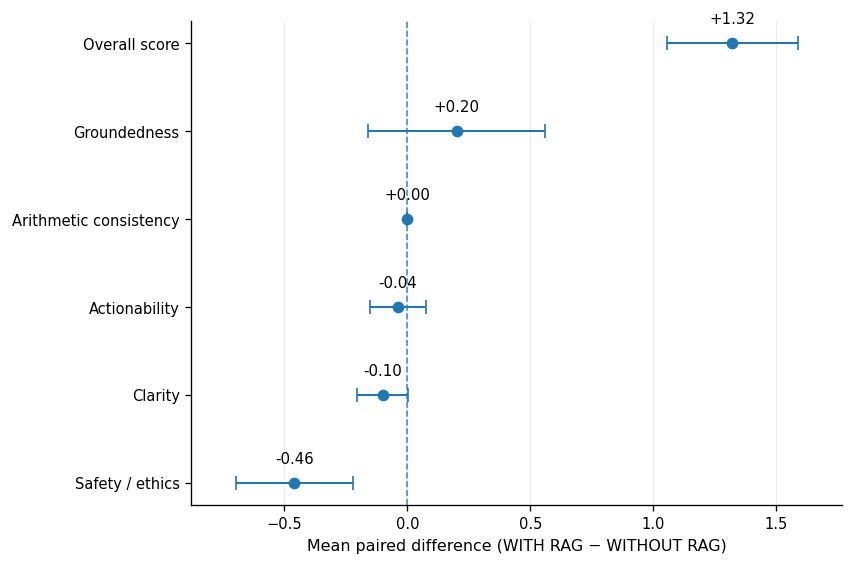

In [23]:
metrics_order = [
    "overall_score",
    "score_groundedness",
    "score_arithmetic_consistency",
    "score_actionability",
    "score_clarity",
    "score_safety_ethics",
]

pretty = {
    "overall_score": "Overall score",
    "score_groundedness": "Groundedness",
    "score_arithmetic_consistency": "Arithmetic consistency",
    "score_actionability": "Actionability",
    "score_clarity": "Clarity",
    "score_safety_ethics": "Safety / ethics",
}

b = baseline_stats[
    baseline_stats["metric"].isin(metrics_order)
].copy()

b["order"] = b["metric"].map(
    {metric: i for i, metric in enumerate(metrics_order)}
)

# Overall score at the top
b = b.sort_values("order", ascending=False)

y = np.arange(len(b))
x = b["mean_diff"].to_numpy(float)
lo = b["ci95_low"].to_numpy(float)
hi = b["ci95_high"].to_numpy(float)

xerr = np.vstack([
    x - lo,
    hi - x
])

fig, ax = plt.subplots(figsize=(7.2, 4.8))

ax.errorbar(
    x,
    y,
    xerr=xerr,
    fmt="o",
    markersize=6,
    capsize=4,
    elinewidth=1.2,
    linewidth=1.2,
)

# Reference line: no difference between WITH and WITHOUT RAG
ax.axvline(
    0,
    linewidth=1,
    linestyle="--",
    alpha=0.8,
)

ax.set_yticks(y)
ax.set_yticklabels([pretty[m] for m in b["metric"]])

ax.set_xlabel(
    "Mean paired difference (WITH RAG − WITHOUT RAG)"
)

# No title here — it will be provided in the figure caption
ax.set_title("")

# Horizontal padding so confidence intervals and labels are not clipped
xmin = min(lo) - 0.18
xmax = max(hi) + 0.18
ax.set_xlim(xmin, xmax)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

# Put effect estimates ABOVE the points, not on the CI lines
for yi, xi in zip(y, x):
    ax.annotate(
        f"{xi:+.2f}",
        xy=(xi, yi),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Remove unnecessary frame elements
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

save_figure(
    fig,
    "fig2_rag_ablation_effects"
)

### Supplementary figure S2 — routing by RAG condition
The routing counts are reported in the Results; the chart is supplementary.


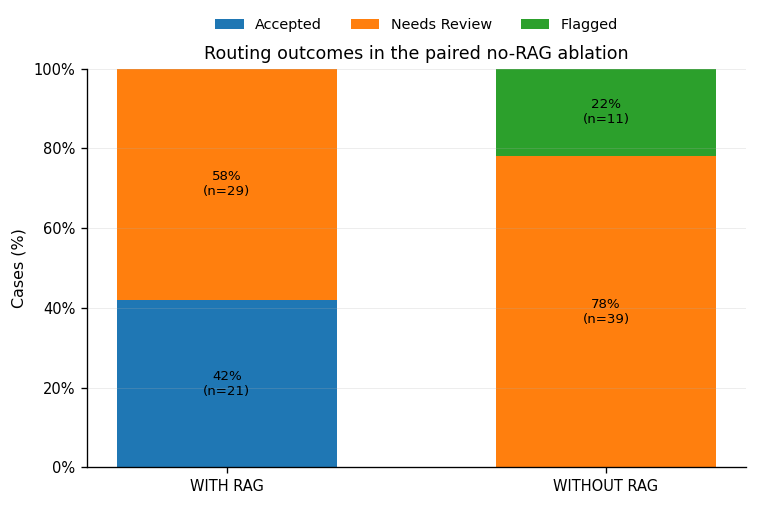

In [17]:
br = baseline_routing.set_index("condition")
cats = ["accepted", "needs_review", "flagged"]
cond_labels = ["WITH RAG", "WITHOUT RAG"]
data = np.array([[br.loc["with_rag", c] for c in cats],
                 [br.loc["without_rag", c] for c in cats]], dtype=float)
pct = data / data.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6.4, 4.3))
xpos = np.arange(2)
bottom = np.zeros(2)
for j, c in enumerate(cats):
    bars = ax.bar(xpos, pct[:,j], bottom=bottom, width=0.58,
                  label=c.replace("_"," ").title())
    for i, bar in enumerate(bars):
        if pct[i,j] >= 8:
            ax.text(bar.get_x()+bar.get_width()/2, bottom[i]+pct[i,j]/2,
                    f"{pct[i,j]:.0f}%\n(n={int(data[i,j])})",
                    ha="center", va="center", fontsize=8)
    bottom += pct[:,j]

ax.set_xticks(xpos, cond_labels)
ax.set_ylabel("Cases (%)")
ax.set_ylim(0,100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.set_title("Routing outcomes in the paired no-RAG ablation")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.16))
ax.grid(axis="y")
save_figure(fig, "fig3_rag_ablation_routing", manuscript=False)


### Manuscript interpretation

The no-RAG ablation supports a bounded claim: RAG substantially changes the composite score and downstream routing, mainly through citation/source-grounding infrastructure. It does **not** demonstrate across-the-board improvement in factual correctness or every rubric dimension.


## 3. Repeated-run stability

One hundred fixed profiles were replayed five times through the Consultant → Evaluator → routing stage. Inputs were held fixed; live retrieval and model inference were rerun.


In [18]:
repeated_profile = read_sheet("Repeated_Profile")
repeated_scores = read_sheet("Repeated_Scores")
routing_agreement = read_sheet("Routing_Agreement")

display(Markdown("**Profile-level routing stability**"))
display(repeated_profile[[
    "group", "n_repeats", "score_mean", "score_sd", "score_range",
    "modal_routing", "pct_matching_modal", "all_repeats_identical_routing"
]].head(15))

display(Markdown("**Score variability and ICC(2,1)**"))
display(repeated_scores)

display(Markdown("**Routing agreement summary**"))
display(routing_agreement)


**Profile-level routing stability**

,group,n_repeats,score_mean,score_sd,score_range,modal_routing,pct_matching_modal,all_repeats_identical_routing
0,0,5,8.0,0.000,0,needs_review,100,True
1,1,5,9.0,0.000,0,accepted,100,True
2,2,5,8.2,0.837,2,needs_review,60,False
3,3,5,8.4,0.548,1,needs_review,60,False
4,4,5,7.6,1.517,3,accepted,40,False
5,5,5,8.4,0.548,1,needs_review,60,False
6,6,5,7.4,0.548,1,needs_review,100,True
7,7,5,8.4,0.548,1,needs_review,60,False
8,8,5,8.2,0.447,1,needs_review,80,False
9,9,5,8.2,0.837,2,needs_review,60,False


**Score variability and ICC(2,1)**

,dimension,grand_mean,mean_within_profile_sd,max_within_profile_sd,pct_profiles_zero_variance,icc21,icc_note
0,overall_score,8.308,0.5537,1.6733,12,0.1422,NaN
1,score_groundedness,7.992,0.0144,0.5477,97,0.1206,NaN
2,score_arithmetic_consistency,10.000,0.0000,0.0000,100,NaN,NaN
3,score_actionability,8.118,0.1999,0.5477,58,0.2283,NaN
4,score_clarity,8.996,0.0089,0.4472,98,-0.0025,NaN
5,score_safety_ethics,8.432,0.3533,0.5477,30,0.2694,NaN


**Routing agreement summary**

,metric,value
0,n profiles,100
1,repeats per profile,5
2,total repeated runs,500
3,% profiles identical routing in all repeats,14
4,mean % repeats matching modal routing,73.2
5,Fleiss kappa (routing),0.1308
6,mean pairwise Jaccard (issue-type sets),0.5278
7,routing distribution (all repeats),"{""needs_review"": 285, ""accepted"": 203, ""flagge..."
8,mean within-profile SD of overall_score,0.5537
9,% profiles with 0 overall_score variance,12


### Main manuscript Figure — repeated-run routing stability
This is the second recommended main-text figure because it directly addresses the reproducibility concern raised in review.


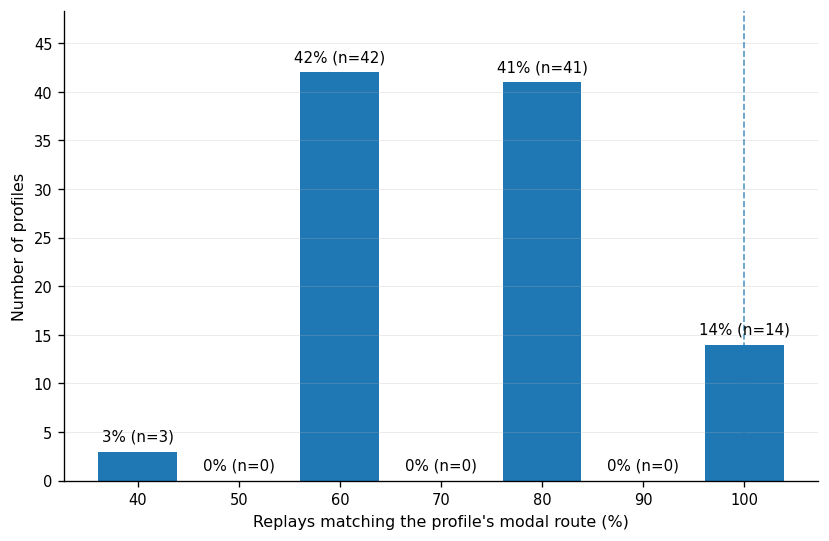

In [26]:
fig, ax = plt.subplots(figsize=(7.0, 4.6))

bins = np.arange(35, 106, 10)

counts, edges, patches = ax.hist(
    repeated_profile["pct_matching_modal"],
    bins=bins,
    rwidth=0.78
)

# Perfect routing agreement
ax.axvline(
    100,
    linewidth=1.0,
    linestyle="--",
    alpha=0.75
)

ax.set_xlabel(
    "Replays matching the profile's modal route (%)"
)
ax.set_ylabel("Number of profiles")

# No title — it will be included in the LaTeX caption
ax.set_title("")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Extra vertical space for labels
ax.set_ylim(0, max(counts) * 1.15)

# Labels above all bars
total_profiles = len(repeated_profile)

for count, patch in zip(counts, patches):
    pct = (count / total_profiles) * 100

    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.8,
        f"{pct:.0f}% (n={int(count)})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

save_figure(
    fig,
    "fig4_repeated_routing_stability"
)

### Supplementary figure S3 — score variability by dimension
This decomposition supports the interpretation of the repeated-run experiment but does not need to appear in the main manuscript.


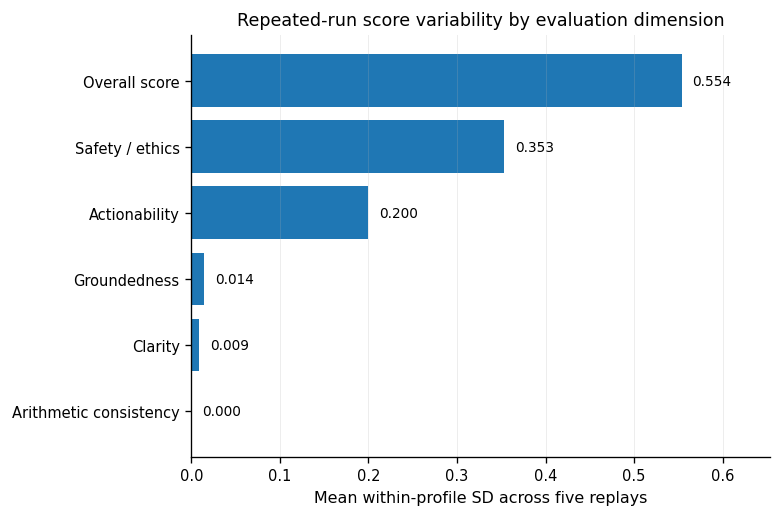

In [20]:
plot = repeated_scores.copy()
pretty_dim = {
    "overall_score":"Overall score",
    "score_groundedness":"Groundedness",
    "score_arithmetic_consistency":"Arithmetic consistency",
    "score_actionability":"Actionability",
    "score_clarity":"Clarity",
    "score_safety_ethics":"Safety / ethics",
}
plot["label"] = plot["dimension"].map(pretty_dim)
plot = plot.sort_values("mean_within_profile_sd", ascending=True)

fig, ax = plt.subplots(figsize=(6.6, 4.4))
bars = ax.barh(plot["label"], plot["mean_within_profile_sd"])
ax.set_xlabel("Mean within-profile SD across five replays")
ax.set_title("Repeated-run score variability by evaluation dimension")
ax.grid(axis="x")
for bar, v in zip(bars, plot["mean_within_profile_sd"]):
    ax.text(v + 0.012, bar.get_y()+bar.get_height()/2, f"{v:.3f}",
            va="center", fontsize=8.2)
ax.set_xlim(0, max(plot["mean_within_profile_sd"])*1.18)
save_figure(fig, "fig5_repeated_dimension_variability", manuscript=False)


### Manuscript interpretation

Deterministic arithmetic was fully reproducible, but routing was not a stable single-run property. Only 14% of profiles had identical routing across all five replays; Fleiss' κ was 0.131. The manuscript should therefore present the routing layer as a conservative triage mechanism whose output remains sensitive to stochastic model and retrieval variation.


## 4. Exploratory subgroup and synthetic-budget checks

These analyses address reviewer questions about subgroup behaviour and generator feasibility. They are exploratory because all profiles are synthetic and generated by interdependent simulation rules.


In [21]:
subgroup_descr = read_sheet("Subgroup_Descr")
subgroup_tests = read_sheet("Subgroup_Tests")
effect_sizes = read_sheet("Effect_Sizes")
budget_stats = read_sheet("Budget_Stats")

display(Markdown("**Synthetic budget characteristics**"))
display(budget_stats)

display(Markdown("**Exploratory subgroup tests for overall score**"))
display(subgroup_tests[subgroup_tests["outcome"]=="overall_score"])

display(Markdown("**Corresponding effect sizes**"))
display(effect_sizes[effect_sizes["outcome"]=="overall_score"])


**Synthetic budget characteristics**

,metric,value
0,n cases,500.0
1,deficit cases (surplus<=0),75.0
2,deficit pct,15.0
3,surplus mean (PLN),217.4
4,surplus median (PLN),240.0
5,surplus sd (PLN),319.4
6,surplus min (PLN),-1410.0
7,surplus max (PLN),1480.0
8,surplus p1,-810.1
9,surplus p5,-451.0


**Exploratory subgroup tests for overall score**

,grouping,outcome,test,k_groups,anova_F,anova_p,kruskal_H,kruskal_p,note,mean_diff(a_minus_b),n1,n2,welch_t,welch_p,mwu_U,mwu_p
0,employment_status,overall_score,ANOVA + Kruskal-Wallis,5.0,0.718001,0.5799,1.658681,0.798209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,surplus_position,overall_score,Welch t + Mann-Whitney U,NaN,NaN,NaN,NaN,NaN,NaN,-0.045,75.0,425.0,-0.3936,0.6949,16225.5,0.7689
12,dependents,overall_score,Welch t + Mann-Whitney U,NaN,NaN,NaN,NaN,NaN,NaN,0.102,340.0,160.0,1.8450,0.0659,29967.5,0.0304


**Corresponding effect sizes**

,grouping,outcome,eta_squared,epsilon_squared,cohens_d,hedges_g
0,employment_status,overall_score,0.0058,-0.0047,NaN,NaN
6,surplus_position,overall_score,NaN,NaN,-0.0733,-0.0732
12,dependents,overall_score,NaN,NaN,0.1674,0.1671


### Reporting boundary

The synthetic deficit/surplus distribution is a property of the computational testbed and must not be interpreted as a population estimate for displaced Ukrainians in Poland. Subgroup tests are descriptive/exploratory and should not be given causal interpretation.


## 5. Manuscript-ready numerical summary


In [22]:
manuscript_summary = pd.DataFrame([
    ["Original routing, N=500", "327 accepted / 170 needs_review / 3 flagged"],
    ["Issue severity", "602 low / 25 medium / 0 high"],
    ["Arithmetic safeguard", "0/500 deterministic arithmetic mismatches; mean score 9.99"],
    ["Synthetic budget", "75/500 deficit profiles (15.0%); median monthly surplus PLN 240"],
    ["No-RAG ablation", "overall score 8.40 WITH vs 7.08 WITHOUT; paired Δ=+1.32, 95% CI [1.05, 1.59], dz=1.41"],
    ["No-RAG routing", "WITH: 21 accepted / 29 needs_review / 0 flagged; WITHOUT: 0 / 39 / 11"],
    ["Repeated routing stability", "14% identical routing across all five replays; Fleiss' κ=0.131"],
    ["Repeated score variability", "mean within-profile SD of overall score=0.554"],
    ["Repeated issue stability", "mean pairwise Jaccard=0.528"],
], columns=["Result", "Value"])
display(manuscript_summary)


,Result,Value
0,"Original routing, N=500",327 accepted / 170 needs_review / 3 flagged
1,Issue severity,602 low / 25 medium / 0 high
2,Arithmetic safeguard,0/500 deterministic arithmetic mismatches; mea...
3,Synthetic budget,75/500 deficit profiles (15.0%); median monthl...
4,No-RAG ablation,overall score 8.40 WITH vs 7.08 WITHOUT; paire...
5,No-RAG routing,WITH: 21 accepted / 29 needs_review / 0 flagge...
6,Repeated routing stability,14% identical routing across all five replays;...
7,Repeated score variability,mean within-profile SD of overall score=0.554
8,Repeated issue stability,mean pairwise Jaccard=0.528


## Interpretation boundaries

- `accepted` means passed predefined automated criteria; it does not mean human-expert approval.
- The Evaluator Agent is architecturally separate from the Consultant Agent but was not validated against human experts in this study.
- Near-perfect arithmetic consistency reflects deterministic recomputation.
- RAG's demonstrated effect is primarily on citation/source-grounding and routing, not universal factual-quality improvement.
- Single-run routing labels are sensitive to stochastic variation and should not be presented as perfectly stable system properties.
- Synthetic-profile statistics are properties of the testbed, not population estimates.
